## [함수] '반경 500m 동일 업종'
** TA 전달용

In [1]:
import numpy as np
import pandas as pd

def haversine(lat1, lon1, lat2, lon2):
    """두 좌표 간 거리(m) 계산"""
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def filter_nearby(df: pd.DataFrame, center_lat: float, center_lon: float, radius_m: float = 500) -> pd.DataFrame:
    """
    반경 필터링 함수

    Parameters
    ----------
    df : pd.DataFrame
        소상공인 상권데이터 (경도, 위도 컬럼 필수)
    center_lat, center_lon : float
        기준점(사용자 입력 위치) 위도/경도
    radius_m : float
        반경(미터), 기본 500m

    Returns
    -------
    pd.DataFrame
        반경 내 업체만 필터링 + distance_m 컬럼 추가, 가까운 순 정렬
    """
    required_cols = {'위도', '경도'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"필수 컬럼 누락: {missing}")

    clean_df = df.dropna(subset=['위도', '경도']).copy()
    clean_df = clean_df[(clean_df['위도'] != 0) & (clean_df['경도'] != 0)]

    clean_df['distance_m'] = haversine(
        center_lat, center_lon,
        clean_df['위도'].values, clean_df['경도'].values
    )

    nearby = clean_df[clean_df['distance_m'] <= radius_m].copy()
    nearby = nearby.sort_values('distance_m').reset_index(drop=True)

    return nearby
    
### 기존 함수

# def get_dong_center(df: pd.DataFrame, sido: str, sigungu: str, dong: str) -> tuple:
#     """
#     동 이름 → 대표 좌표(centroid) 계산
#     """
#     target = df[
#         (df['시도명'] == sido) &
#         (df['시군구명'] == sigungu) &
#         (df['행정동명'] == dong)
#     ]

#     if len(target) == 0:
#         raise ValueError(f"'{sido} {sigungu} {dong}'에 해당하는 데이터가 없습니다.")

#     center_lat = target['위도'].mean()
#     center_lon = target['경도'].mean()

#     return center_lat, center_lon

### 동 공백 문제 해결 ver.
def get_dong_center(df: pd.DataFrame, sido: str, sigungu: str, dong: str) -> tuple:
    """
    동 이름 → 대표 좌표(centroid) 계산
    (공백 표기 차이 방지를 위해 정규화 후 비교)
    """
    def normalize(s):
        return str(s).replace(" ", "").strip()

    target = df[
        (df['시도명'].apply(normalize) == normalize(sido)) &
        (df['시군구명'].apply(normalize) == normalize(sigungu)) &
        (df['행정동명'].apply(normalize) == normalize(dong))
    ]

    if len(target) == 0:
        raise ValueError(f"'{sido} {sigungu} {dong}'에 해당하는 데이터가 없습니다.")

    center_lat = target['위도'].mean()
    center_lon = target['경도'].mean()

    return center_lat, center_lon


def analyze_by_dong(df: pd.DataFrame, sido: str, sigungu: str, dong: str, radius_m: float = 500) -> pd.DataFrame:
    """
    동 이름 입력 → 좌표 변환 → 반경 필터링까지 한번에
    """
    center_lat, center_lon = get_dong_center(df, sido, sigungu, dong)
    nearby = filter_nearby(df, center_lat, center_lon, radius_m)
    return nearby

def count_same_industry(nearby_df: pd.DataFrame, target_codes, code_col: str = '표준산업분류코드') -> int:
    """
    반경 내 동일업종 카운트 함수 (표준산업분류코드 기준)
    """
    if isinstance(target_codes, str):
        target_codes = [target_codes]
    if code_col not in nearby_df.columns:
        raise ValueError(f"'{code_col}' 컬럼이 존재하지 않습니다.")
    return int(nearby_df[code_col].isin(target_codes).sum())

    
# 사용 예시
# df = pd.read_csv("../../../data/상권 분석 리포트/소상공인 상권/소상공인시장진흥공단_상가(상권)정보_경기_202603_v2prep.xls", encoding="utf-8-sig")
# nearby = filter_nearby(df, center_lat=37.4848437674076, center_lon=126.993690874112, radius_m=500)
# print(f"반경 내 업체 수: {len(nearby)}건")
# nearby.head()

## [함수] '동일 업종 밀집도'
** TA 전달용

In [2]:
import numpy as np
import pandas as pd

def compute_density_grid(
    nearby_df: pd.DataFrame,
    center_lat: float,
    center_lon: float,
    target_codes,
    code_col: str = '표준산업분류코드',
    radius_m: float = 500,
    grid_size: int = 5
) -> dict:
    """
    동일업종 밀집도 격자화 함수 (표준산업분류코드 기준)

    반경 내 업체 중 사용자와 동일업종(target_codes)에 해당하는 업체들만 골라,
    중심좌표 기준 상대 위치를 grid_size x grid_size 격자 칸으로 변환하여
    칸별 밀집도(개수)를 계산한다. 화면의 히트맵/격자 시각화에 그대로 사용 가능.

    Parameters
    ----------
    nearby_df : pd.DataFrame
        반경 필터링된 결과 (filter_nearby / analyze_by_dong의 반환값)
    center_lat, center_lon : float
        기준 중심좌표 (analyze_by_dong 호출 시 get_dong_center로 계산된 값과 동일해야 함)
    target_codes : str or list[str]
        동일업종 판별 기준 표준산업분류코드 (count_same_industry와 동일한 값 사용 권장)
    code_col : str
        코드 비교 컬럼명 (기본: 표준산업분류코드)
    radius_m : float
        반경(미터). nearby_df를 만들 때 사용한 반경과 동일해야 격자 범위가 정확함 (기본 500m)
    grid_size : int
        격자 한 변의 칸 수 (기본 5x5 = 25칸)

    Returns
    -------
    dict
        {
            "grid_size": int,
            "center_cell": [x, y],       # 사용자 위치(중심점)가 위치한 격자 칸
            "cells": [{"x":.., "y":.., "count":..}, ...]  # 업체가 1개 이상 있는 칸만 포함
        }
    """
    if isinstance(target_codes, str):
        target_codes = [target_codes]

    if code_col not in nearby_df.columns:
        raise ValueError(f"'{code_col}' 컬럼이 존재하지 않습니다.")

    # 1. 동일업종만 필터링
    same_industry = nearby_df[nearby_df[code_col].isin(target_codes)].copy()

    # 동일업종이 하나도 없으면 빈 격자 반환 (에러 대신 안전하게 처리)
    if len(same_industry) == 0:
        return {
            "grid_size": grid_size,
            "center_cell": [grid_size // 2, grid_size // 2],
            "cells": []
        }

    # 2. 중심점 기준 상대좌표(m 단위)로 변환
    #    - dx: 동서 방향 거리 (중심보다 동쪽이면 +, 서쪽이면 -)
    #    - dy: 남북 방향 거리 (중심보다 북쪽이면 +, 남쪽이면 -)
    def to_meters(lat, lon, center_lat, center_lon):
        dx = haversine(center_lat, center_lon, center_lat, lon) * np.where(lon > center_lon, 1, -1)
        dy = haversine(center_lat, center_lon, lat, center_lon) * np.where(lat > center_lat, 1, -1)
        return dx, dy

    dx, dy = to_meters(
        same_industry['위도'].values, same_industry['경도'].values,
        center_lat, center_lon
    )
    same_industry['dx'] = dx
    same_industry['dy'] = dy

    # 3. 상대좌표(m)를 격자 칸 인덱스로 변환
    #    전체 반경(지름 = radius_m*2)을 grid_size 칸으로 나눠서 한 칸의 크기(m) 계산
    cell_meters = (radius_m * 2) / grid_size
    same_industry['grid_x'] = (same_industry['dx'] / cell_meters + grid_size // 2).astype(int).clip(0, grid_size - 1)
    same_industry['grid_y'] = (same_industry['dy'] / cell_meters + grid_size // 2).astype(int).clip(0, grid_size - 1)

    # 4. 칸별 업체 개수 집계
    grid_counts = (
        same_industry.groupby(['grid_x', 'grid_y'])
        .size()
        .reset_index(name='count')
    )

    cells = [
        {"x": int(row['grid_x']), "y": int(row['grid_y']), "count": int(row['count'])}
        for _, row in grid_counts.iterrows()
    ]

    return {
        "grid_size": grid_size,
        "center_cell": [grid_size // 2, grid_size // 2],
        "cells": cells
    }

## [검증] 반경 500M 내 업체수

In [3]:
# ============================================
# analyze_by_dong() 함수 테스트
# 실제 화면(TA)에서는 사용자가 시/도 - 시군구 - 동 드롭다운으로 위치를 선택하므로,
# 동 이름 → 중심좌표(centroid) 변환 → 반경 필터링까지 한번에 처리하는 함수로 검증
# ============================================

# DA 테스트 (UI 드롭다운 형식에 맞춰 '동' 이름으로 위치를 받았을 경우)
# 대상: 경기도 고양시 덕양구 흥도동, 반경 500m
df = pd.read_csv("../../../data/상권 분석 리포트/소상공인 상권/소상공인시장진흥공단_상가(상권)정보_경기_202603_v2prep.xls", encoding="utf-8-sig")
center_lat, center_lon = get_dong_center(df, sido="경기도", sigungu="고양시 덕양구", dong="흥도동")
nearby_dong = analyze_by_dong(df, sido="경기도", sigungu="고양시 덕양구", dong="흥도동", radius_m=500)
print(f"흥도동 반경 500m 내 업체 수: {len(nearby_dong)}건")

흥도동 반경 500m 내 업체 수: 422건


In [4]:
# ============================================
# count_same_industry() 함수 검증 테스트
# nearby_dong: 흥도동(경기도 고양시 덕양구) 반경 500m 내 업체 목록 (422건)
# ============================================

# 1. 반경 내 실제 존재하는 표준산업분류코드 확인 (상위 10개, 건수 많은 순)
print(nearby_dong['표준산업분류코드'].value_counts().head(10))

# 2. 단일 코드 테스트
# I56221 = 커피전문점 → value_counts() 결과 17건과 일치해야 정상
count = count_same_industry(nearby_dong, target_codes="I56221")
print(f"흥도동 반경 500m 내 I56221(커피전문점) 수: {count}곳")

# 3. 리스트(다중 코드) 입력 테스트
# 실제 서비스에서는 업종코드 하나가 표준산업분류코드 여러 개로 매핑될 수 있어
# 여러 코드를 리스트로 넘겼을 때 합산이 정확한지 검증
# I56111(한식 일반 음식점업, 24건) + I56221(커피전문점, 17건) → 24+17=41이 나와야 정상
# (두 코드는 실제 업종 연관성 없이 테스트 목적으로 임의 선정)
count_multi = count_same_industry(nearby_dong, target_codes=["I56111", "I56221"])
print(f"흥도동 반경 500m 내 I56111+I56221 합산: {count_multi}곳")

# 4. 존재하지 않는 코드 입력 테스트
# 매핑 오류 등으로 잘못된 코드가 들어와도 에러 없이 0을 반환하는지 확인
count_none = count_same_industry(nearby_dong, target_codes="Z99999")
print(f"존재하지 않는 코드 결과: {count_none}곳")

표준산업분류코드
M71531    40
I56111    24
M73203    22
M71310    17
I56221    17
L68221    16
M72129    16
M72111    14
N75992    10
M73201     9
Name: count, dtype: int64
흥도동 반경 500m 내 I56221(커피전문점) 수: 17곳
흥도동 반경 500m 내 I56111+I56221 합산: 41곳
존재하지 않는 코드 결과: 0곳


## [검증] 동일업종 밀집도

In [5]:
# 1. compute_density_grid 실행 (grid_size 생략하면 기본값 5 적용됨)
density_result = compute_density_grid(
    nearby_dong,
    center_lat=center_lat,
    center_lon=center_lon,
    target_codes="I56221",
    radius_m=500
)

# 2. 검증: 격자 합계가 17이 나와야 정상 (count_same_industry 결과와 동일)
total_in_grid = sum(cell['count'] for cell in density_result['cells'])
print(f"격자 내 총 카운트: {total_in_grid}")

격자 내 총 카운트: 17


In [6]:
# 격자 안의 count 총합
total_in_grid = sum(cell['count'] for cell in density_result['cells'])
print(f"격자 내 총 카운트: {total_in_grid}")

# count_same_industry 결과와 비교 (아까 17이 나왔던 것)
count_check = count_same_industry(nearby_dong, target_codes="I56221")
print(f"count_same_industry 결과: {count_check}")

print(f"두 값이 일치하는가: {total_in_grid == count_check}")

격자 내 총 카운트: 17
count_same_industry 결과: 17
두 값이 일치하는가: True


## [시각화] '동일 업종 밀집도'

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 한글 폰트 설정 (환경에 맞게 폰트명 조정 필요할 수 있음)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기준, Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


def plot_density_grid(density_result: dict, title: str = "동일업종 밀집도"):
    """
    compute_density_grid() 결과를 히트맵으로 시각화

    Parameters
    ----------
    density_result : dict
        compute_density_grid()의 반환값
    title : str
        차트 제목
    """
    grid_size = density_result['grid_size']
    center_x, center_y = density_result['center_cell']

    # 격자 매트릭스 초기화 (0으로 채움)
    matrix = np.zeros((grid_size, grid_size))

    for cell in density_result['cells']:
        matrix[cell['y'], cell['x']] = cell['count']

    fig, ax = plt.subplots(figsize=(6, 6))

    # 히트맵 그리기
    im = ax.imshow(matrix, cmap='Oranges', origin='lower')

    # 각 칸에 숫자 표시
    for y in range(grid_size):
        for x in range(grid_size):
            count = int(matrix[y, x])
            if count > 0:
                ax.text(x, y, str(count), ha='center', va='center',
                         color='white' if count >= matrix.max() * 0.5 else 'black',
                         fontsize=11, fontweight='bold')

    # 중심점(사용자 위치) 표시
    ax.scatter([center_x], [center_y], color='black', s=100, zorder=5, marker='o')
    ax.text(center_x, center_y - 0.35, '내 위치', ha='center', fontsize=9)

    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.set_title(title, fontsize=13)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    plt.colorbar(im, ax=ax, label='업체 수', shrink=0.8)
    plt.tight_layout()
    plt.show()

In C:\Users\asia\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\asia\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\asia\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


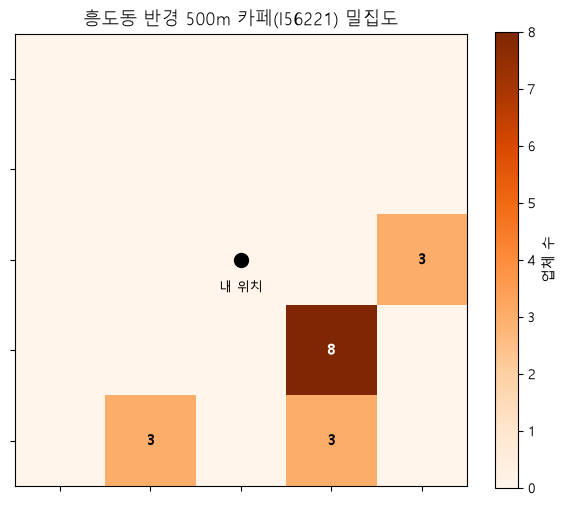

In [8]:
plot_density_grid(density_result, title="흥도동 반경 500m 카페(I56221) 밀집도")

## [소상공인 데이터] 위도/경도 결측치 및 이상치 검증

In [9]:
import pandas as pd
import glob
import os

folder_path = "../../../data/상권 분석 리포트/소상공인 상권/"
csv_files = glob.glob(os.path.join(folder_path, "*.xls"))
print(f"발견된 파일 수: {len(csv_files)}개")
for f in csv_files:
    print(" -", os.path.basename(f))

발견된 파일 수: 15개
 - 소상공인시장진흥공단_상가(상권)정보_강원_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_경기_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_경남_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_경북_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_광주_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_대구_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_대전_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_부산_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_서울_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_세종_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_울산_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_인천_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_전남_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_전북_202603_v2prep.xls
 - 소상공인시장진흥공단_상가(상권)정보_제주_202603_v2prep.xls


In [10]:
def validate_region_data(filepath: str) -> dict:
    """
    지역별 상권데이터 위경도 품질 검증 함수

    하나의 지역 csv 파일을 읽어 위도/경도 컬럼의 결측치, 0값,
    대한민국 범위 이탈, 위경도 뒤바뀜 의심 여부 등을 점검하고
    결과를 요약 딕셔너리로 반환한다.
    (17개 지역 파일을 순회하며 호출하는 용도로 설계됨)

    Parameters
    ----------
    filepath : str
        검증할 지역 csv 파일 경로
        (파일명 형식: ..._{지역명}_{기준연월}_v2prep.csv)

    Returns
    -------
    dict
        지역명, 전체 행 수, 결측/이상치 개수, 시도명 종류,
        위도·경도 최소/최대값 등을 담은 검증 결과
    """
    # 파일명에서 지역명 추출 (예: '..._경기_202603_v2prep.csv' → '경기')
    region_name = os.path.basename(filepath).split("_")[-2]
    df = pd.read_csv(filepath, encoding="utf-8-sig")

    result = {
        "지역": region_name,
        "전체행수": len(df),

        # 결측치 확인: 위도/경도 값이 비어있는 행이 있는지
        "위도_결측": df['위도'].isnull().sum(),
        "경도_결측": df['경도'].isnull().sum(),

        # 0값 확인: 좌표 미수집/오류로 0이 채워진 경우가 있는지
        "위도_0값": (df['위도'] == 0).sum(),
        "경도_0값": (df['경도'] == 0).sum(),

        # 범위 이탈 확인: 대한민국 좌표 범위(위도 33~39, 경도 124~132) 밖 값이 있는지
        "범위이탈": len(df[
            (df['위도'] < 33) | (df['위도'] > 39) |
            (df['경도'] < 124) | (df['경도'] > 132)
        ]),

        # 위경도 뒤바뀜 의심 확인: 위도 자리에 경도값(100 초과)이,
        # 경도 자리에 위도값(50 미만)이 들어간 것으로 보이는 행이 있는지
        "위경도뒤바뀜의심": len(df[
            (df['위도'] > 100) | (df['경도'] < 50)
        ]),

        # 시도명 혼입 확인: 해당 지역 파일에 다른 시/도 데이터가 섞여있는지
        "시도명종류": df['시도명'].nunique(),
        "시도명값": df['시도명'].unique().tolist(),

        # 참고용 기본 통계 (전체적인 좌표 분포 범위 확인)
        "위도_min": df['위도'].min(),
        "위도_max": df['위도'].max(),
        "경도_min": df['경도'].min(),
        "경도_max": df['경도'].max(),
    }
    return result

In [11]:
results = []
for f in csv_files:
    print(f"검증 중: {os.path.basename(f)} ...")
    try:
        res = validate_region_data(f)
        results.append(res)
    except Exception as e:
        print(f"에러 발생: {e}")
        results.append({"지역": os.path.basename(f), "에러": str(e)})

summary_df = pd.DataFrame(results)
summary_df

검증 중: 소상공인시장진흥공단_상가(상권)정보_강원_202603_v2prep.xls ...


검증 중: 소상공인시장진흥공단_상가(상권)정보_경기_202603_v2prep.xls ...


검증 중: 소상공인시장진흥공단_상가(상권)정보_경남_202603_v2prep.xls ...


검증 중: 소상공인시장진흥공단_상가(상권)정보_경북_202603_v2prep.xls ...


검증 중: 소상공인시장진흥공단_상가(상권)정보_광주_202603_v2prep.xls ...


...

검증 중: 소상공인시장진흥공단_상가(상권)정보_세종_202603_v2prep.xls ...
검증 중: 소상공인시장진흥공단_상가(상권)정보_울산_202603_v2prep.xls ...
검증 중: 소상공인시장진흥공단_상가(상권)정보_인천_202603_v2prep.xls ...


검증 중: 소상공인시장진흥공단_상가(상권)정보_전남_202603_v2prep.xls ...


검증 중: 소상공인시장진흥공단_상가(상권)정보_전북_202603_v2prep.xls ...


검증 중: 소상공인시장진흥공단_상가(상권)정보_제주_202603_v2prep.xls ...


,지역,전체행수,위도_결측,경도_결측,위도_0값,경도_0값,범위이탈,위경도뒤바뀜의심,시도명종류,시도명값,위도_min,위도_max,경도_min,경도_max
0,202603,108009,0,0,0,0,0,0,1,[강원특별자치도],37.069963,38.586684,127.145526,129.362228
1,202603,671649,0,0,0,0,0,0,1,[경기도],36.903466,38.231225,126.391044,127.807489
2,202603,168714,0,0,0,0,0,0,1,[경상남도],34.617157,35.902408,127.606908,129.211884
3,202603,141828,0,0,0,0,0,0,1,[경상북도],35.569470,37.545327,127.815011,131.865641
4,202603,75325,0,0,0,0,0,0,1,[광주광역시],35.053972,35.251236,126.652491,127.012680
5,202603,115634,0,0,0,0,0,0,1,[대구광역시],35.618516,36.306790,128.356777,128.870922
6,202603,78607,0,0,0,0,0,0,1,[대전광역시],36.196473,36.493665,127.249113,127.537690
7,202603,155103,0,0,0,0,0,0,1,[부산광역시],34.989747,35.384838,128.801708,129.294072
8,202603,537489,0,0,0,0,0,0,1,[서울특별시],37.430456,37.692604,126.767661,127.182653
9,202603,15423,0,0,0,0,0,0,1,[세종특별자치시],36.410519,36.732433,127.143140,127.407634


In [12]:
problem_regions = summary_df[
    (summary_df['위도_결측'] > 0) |
    (summary_df['경도_결측'] > 0) |
    (summary_df['위도_0값'] > 0) |
    (summary_df['경도_0값'] > 0) |
    (summary_df['범위이탈'] > 0) |
    (summary_df['위경도뒤바뀜의심'] > 0) |
    (summary_df['시도명종류'] > 1)
]

if len(problem_regions) == 0:
    print("모든 지역 데이터 문제 없음")
else:
    print("문제 있는 지역:")
    print(problem_regions)

모든 지역 데이터 문제 없음
